# Model development — AI Data Center Supply Chain Control Tower

Exploration and training notebook behind `src/forecasting/leadtime_model.py` and
`src/risk_model/delay_model.py`. Production logic lives in those modules; this
notebook documents the analysis that led to the choices in `MODEL_DOCUMENTATION.md`.

**All data is synthetic** (seeded, causally generated — see `src/data_generation/generate.py`).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pos = pd.read_csv(ROOT / "data/synthetic/purchase_orders.csv")
print(f"{len(pos)} purchase orders · {pos['supplier_name'].nunique()} suppliers · "
      f"{pos['equipment_category'].nunique()} categories")
pos[["purchase_order_id","equipment_category","supplier_name","planned_lead_time_days",
     "procurement_status","missed_required_date"]].head()

1650 purchase orders · 30 suppliers · 12 categories


,purchase_order_id,equipment_category,supplier_name,planned_lead_time_days,procurement_status,missed_required_date
0,PO-1000,Network Equipment,Arista,97,Delivered,1
1,PO-1001,NVIDIA GPU Systems,NVIDIA,132,In Production,1
2,PO-1002,NVIDIA GPU Systems,NVIDIA,167,Delivered,1
3,PO-1003,Transformers,Hyundai Electric,406,In Production,1
4,PO-1004,GPU Servers,Dell,82,Delivered,1


## 1. What does lead time look like by category?

Long-lead electrical infrastructure (transformers, generators) behaves nothing
like IT gear — any model must capture this spread.

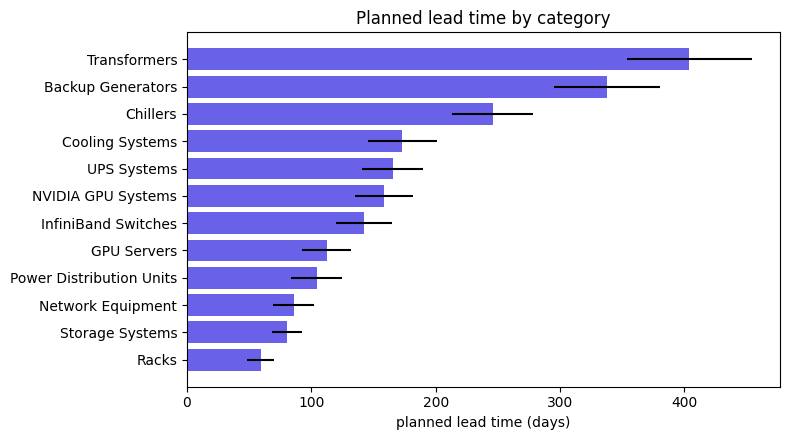

In [2]:
lead = (pos.groupby("equipment_category")["planned_lead_time_days"]
        .agg(["mean","std","count"]).sort_values("mean"))
fig, ax = plt.subplots(figsize=(8,4.5))
ax.barh(lead.index, lead["mean"], xerr=lead["std"], color="#4F46E5", alpha=.85)
ax.set_xlabel("planned lead time (days)"); ax.set_title("Planned lead time by category")
plt.tight_layout(); plt.show()

## 2. Is delay risk causal in the data?

The generator plants a causal process; the check below confirms the signals a
model should recover: capacity-stressed suppliers and constrained categories
miss required dates far more often.

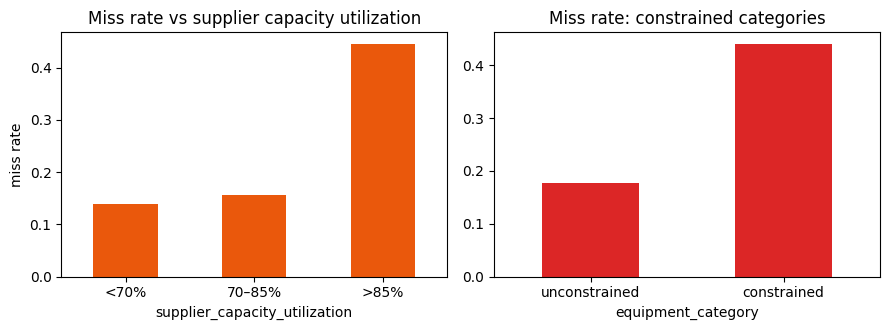

In [3]:
d = pos[pos.procurement_status == "Delivered"].copy()
buckets = pd.cut(d.supplier_capacity_utilization, [0,.7,.85,1.0],
                 labels=["<70%","70–85%",">85%"])
by_util = d.groupby(buckets, observed=True).missed_required_date.mean()
con_cats = ["NVIDIA GPU Systems","InfiniBand Switches","Transformers",
            "Backup Generators","GPU Servers","Cooling Systems"]
by_con = d.groupby(d.equipment_category.isin(con_cats)).missed_required_date.mean()

fig, axes = plt.subplots(1, 2, figsize=(9,3.4))
by_util.plot.bar(ax=axes[0], color="#EA580C", rot=0)
axes[0].set_title("Miss rate vs supplier capacity utilization"); axes[0].set_ylabel("miss rate")
by_con.rename({False:"unconstrained",True:"constrained"}).plot.bar(ax=axes[1], color="#DC2626", rot=0)
axes[1].set_title("Miss rate: constrained categories")
plt.tight_layout(); plt.show()

## 3. Features and the closed-window split

Everything must be knowable at order time (no `current_eta`, no statuses).
Delivered-only data is **right-censored** — recent orders appear only if they
delivered fast — so train/test both restrict to POs whose outcome window
(planned lead + 120 days) has fully closed, then split by order date.

In [4]:
from src.transformation.features import build_features, ALL_FEATURES
from src.forecasting.leadtime_model import time_split, _preprocessor

feats = build_features(pos)
train, test, cutoff = time_split(feats)
print(f"closed-window cohort → train {len(train)} / test {len(test)} (cutoff {cutoff.date()})")

closed-window cohort → train 316 / test 145 (cutoff 2025-09-21)


## 4. Lead-time regression — three models vs the plan itself

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_tr, y_tr = train[ALL_FEATURES], train["actual_lead_time_days"]
X_te, y_te = test[ALL_FEATURES], test["actual_lead_time_days"]

models = {
  "Naive (planned lead)": None,
  "Ridge": Pipeline([("pre", _preprocessor(True)), ("m", Ridge(alpha=1.0))]),
  "Random Forest": Pipeline([("pre", _preprocessor()), ("m", RandomForestRegressor(300, min_samples_leaf=3, random_state=7, n_jobs=-1))]),
  "HistGradientBoosting": Pipeline([("pre", _preprocessor()), ("m", HistGradientBoostingRegressor(max_iter=400, learning_rate=.06, max_depth=6, random_state=7))]),
}
rows = []
for name, pipe in models.items():
    pred = X_te["planned_lead_time_days"] if pipe is None else pipe.fit(X_tr, y_tr).predict(X_te)
    rows.append({"model": name,
                 "MAE": round(mean_absolute_error(y_te, pred), 2),
                 "RMSE": round(float(np.sqrt(mean_squared_error(y_te, pred))), 2),
                 "R2": round(r2_score(y_te, pred), 3)})
pd.DataFrame(rows)

,model,MAE,RMSE,R2
0,Naive (planned lead),26.53,40.99,0.465
1,Ridge,17.82,23.55,0.824
2,Random Forest,16.98,22.33,0.841
3,HistGradientBoosting,17.59,23.79,0.820


## 5. Delay-risk classification — recall-first threshold

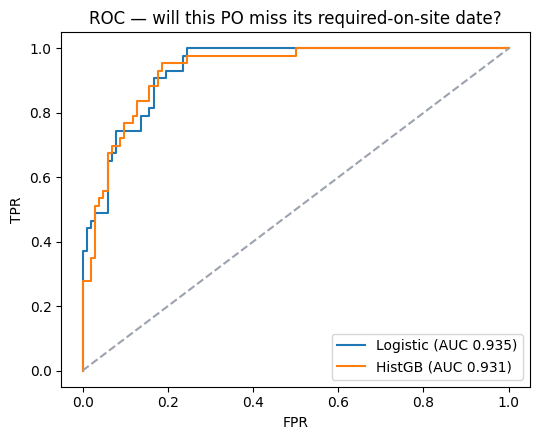

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score

y_tr_c, y_te_c = train["missed_required_date"], test["missed_required_date"]
logit = Pipeline([("pre", _preprocessor(True)), ("m", LogisticRegression(max_iter=3000, C=.5))]).fit(X_tr, y_tr_c)
hgb = Pipeline([("pre", _preprocessor()), ("m", HistGradientBoostingClassifier(max_iter=350, learning_rate=.07, max_depth=6, random_state=7))]).fit(X_tr, y_tr_c)

fig, ax = plt.subplots(figsize=(5.5,4.5))
for name, m in [("Logistic", logit), ("HistGB", hgb)]:
    proba = m.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te_c, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te_c, proba):.3f})")
ax.plot([0,1],[0,1],"--",c="#9CA3AF"); ax.legend(); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC — will this PO miss its required-on-site date?")
plt.tight_layout(); plt.show()

In [7]:
# Operating point: prioritize recall (a missed infrastructure delay costs more
# than a false alarm). Production tunes on train-CV worst-fold recall; shown here on test.
proba = logit.predict_proba(X_te)[:,1]
for t in [0.5, 0.35, 0.27, 0.2]:
    pred = (proba >= t).astype(int)
    print(f"t={t:.2f}  precision={precision_score(y_te_c, pred):.2f}  "
          f"recall={recall_score(y_te_c, pred):.2f}")

t=0.50  precision=0.78  recall=0.74
t=0.35  precision=0.68  recall=0.79
t=0.27  precision=0.70  recall=0.91
t=0.20  precision=0.66  recall=0.93


## 6. Conclusions

- **Lead-time:** tree/linear models cut MAE ~30–40% vs trusting the plan; the
  spread is driven by category, supplier utilization and origin lane.
- **Delay risk:** AUC ≈ 0.9 on the closed-window test; threshold set for
  recall ≥ 0.8 because unflagged delays are the expensive failure mode.
- **Limitations:** long-lead categories (transformers, generators) are sparse
  in any closed-window cohort — their predictions extrapolate; censoring is
  inherent to delivered-only training data; synthetic data understates
  real-world messiness (see `MODEL_DOCUMENTATION.md §7`).